# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")

## Carregue os dados

In [3]:
# Carregue os arquivos de dados em diferentes DataFrames
try:
    df_plans = pd.read_csv('/datasets/megaline_plans.csv')
    df_users = pd.read_csv('/datasets/megaline_users.csv')
    df_calls = pd.read_csv('/datasets/megaline_calls.csv')
    df_messages = pd.read_csv('/datasets/megaline_messages.csv')
    df_internet = pd.read_csv('/datasets/megaline_internet.csv')
except FileNotFoundError:
    # Caminho alternativo caso os dados estejam locais
    df_plans = pd.read_csv('megaline_plans.csv')
    df_users = pd.read_csv('megaline_users.csv')
    df_calls = pd.read_csv('megaline_calls.csv')
    df_messages = pd.read_csv('megaline_messages.csv')
    df_internet = pd.read_csv('megaline_internet.csv')

## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Planos

In [4]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [5]:
# Imprima uma amostra de dados dos planos

display(df_plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

R: O DataFrame plans contém 2 linhas e 8 colunas correspondentes às regras dos dois planos (Surf e Ultimate). Não há valores ausentes. A coluna mb_per_month_included está em megabytes, devendo ser convertida para gigabytes ao comparar com o consumo final dos usuários ($1024 \text{ MB} = 1 \text{ GB}$).

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [6]:
'Não há erros ou valores ausentes na tabela de planos.'

'Não há erros ou valores ausentes na tabela de planos.'

## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [7]:
# Convertendo mb_per_month_included para gb_per_month_included para facilitar comparações
df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024

# CÓDIGO CORRIGIDO: mudando 'usd_monthly_fee' para 'usd_monthly_pay'
display(df_plans[['plan_name', 'gb_per_month_included', 'usd_monthly_pay']])

,plan_name,gb_per_month_included,usd_monthly_pay
0,surf,15.0,20
1,ultimate,30.0,70


## Usuários

In [8]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [9]:
# Imprima uma amostra de dados dos usuários
display(df_users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

R: reg_date e churn_date estão armazenadas como object (string). Devem ser convertidas para datetime.

churn_date possui muitos valores nulos, o que é esperado (indica que o cliente ainda utiliza o plano).

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [10]:
# Correção do tipo das datas
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [11]:
# Adicionar coluna indicando se o usuário cancelou o plano em 2018
df_users['is_active'] = df_users['churn_date'].isna()
display(df_users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_active
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,True
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,True
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,True
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,True
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,True


## Chamadas

In [12]:

# Imprima informações gerais/resumo sobre o DataFrame das chamadas
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [13]:
# Imprima uma amostra de dados das chamadas
display(df_calls.head())


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

R: call_date está como object e precisa ser convertida para datetime.Conforme regras do negócio da Megaline, cada chamada individual deve ser arredondada para cima em minutos.Chamadas com duration igual a $0.0$ representam chamadas perdidas. Elas não consomem minutos, mas devem ser mantidas na contagem total de tentativas de ligação se necessário.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [14]:
# Converter data da chamada
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

# Arredondar a duração da chamada para cima individualmente (regra Megaline)
df_calls['duration_rounded'] = np.ceil(df_calls['duration'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [15]:
# Extrair o mês da chamada
df_calls['month'] = df_calls['call_date'].dt.month
display(df_calls.head())

,id,user_id,call_date,duration,duration_rounded,month
0,1000_93,1000,2018-12-27,8.52,9.0,12
1,1000_145,1000,2018-12-27,13.66,14.0,12
2,1000_247,1000,2018-12-27,14.48,15.0,12
3,1000_309,1000,2018-12-28,5.76,6.0,12
4,1000_380,1000,2018-12-30,4.22,5.0,12


## Mensagens

In [16]:

# Imprima informações gerais/resumo sobre o DataFrame das mensagens
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [17]:

# Imprima uma amostra dos dados das mensagens
display(df_messages.head())

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

R: message_date precisa ser convertida de object para datetime.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [18]:
# Converter data da mensagem
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [19]:
# Extrair o mês da mensagem
df_messages['month'] = df_messages['message_date'].dt.month
display(df_messages.head())

,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


## Internet

In [20]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [21]:
# Imprima uma amostra de dados para o tráfego da internet
display(df_internet.head())

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

R: session_date precisa ser convertida para datetime.

Diferente das chamadas, as sessões individuais de web não são arredondadas para cima. O arredondamento de MB para GB é feito apenas no total mensal acumulado do usuário.

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [22]:
# Converter data da sessão
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [23]:
# Extrair o mês da sessão de internet
df_internet['month'] = df_internet['session_date'].dt.month
display(df_internet.head())

,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [24]:
# Extrair o mês da sessão de internet
df_internet['month'] = df_internet['session_date'].dt.month
display(df_internet.head())

,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [25]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
calls_count = df_calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_count.rename(columns={'id': 'calls_made'}, inplace=True)


In [26]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
calls_minutes = df_calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()
calls_minutes.rename(columns={'duration_rounded': 'minutes_used'}, inplace=True)

In [27]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
messages_count = df_messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_count.rename(columns={'id': 'messages_sent'}, inplace=True)


In [28]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
internet_usage = df_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

In [29]:

# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
df_monthly = calls_minutes.merge(calls_count, on=['user_id', 'month'], how='outer')
df_monthly = df_monthly.merge(messages_count, on=['user_id', 'month'], how='outer')
df_monthly = df_monthly.merge(internet_usage, on=['user_id', 'month'], how='outer')

# Preencher NAs com 0 (meses sem registro de determinada atividade)
df_monthly.fillna({'minutes_used': 0, 'calls_made': 0, 'messages_sent': 0, 'mb_used': 0}, inplace=True)

# Arredondar a soma mensal de MB para GB para cima (regra Megaline)
df_monthly['gb_used'] = np.ceil(df_monthly['mb_used'] / 1024)

In [30]:

# Adicione as informações sobre o plano
df_monthly = df_monthly.merge(df_users[['user_id', 'city', 'plan']], on='user_id', how='left')
df_monthly = df_monthly.merge(df_plans, left_on='plan', right_on='plan_name', how='left')

display(df_monthly.head())

,user_id,month,minutes_used,calls_made,messages_sent,mb_used,gb_used,city,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,1000,12,124.0,16.0,11.0,1901.47,2.0,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0
1,1001,8,182.0,27.0,30.0,6919.15,7.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15360,500,20,10,0.03,0.03,surf,15.0
2,1001,9,315.0,49.0,44.0,13314.82,14.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15360,500,20,10,0.03,0.03,surf,15.0
3,1001,10,393.0,65.0,53.0,22330.49,22.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15360,500,20,10,0.03,0.03,surf,15.0
4,1001,11,426.0,64.0,36.0,18504.30,19.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,50,15360,500,20,10,0.03,0.03,surf,15.0


[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [32]:
# Calcule a receita mensal para cada usuário
def calculate_revenue(row):
    minutes_over = max(0, row['minutes_used'] - row['minutes_included'])
    messages_over = max(0, row['messages_sent'] - row['messages_included'])
    gb_over = max(0, row['gb_used'] - (row['mb_per_month_included'] / 1024))
    
    cost_minutes = minutes_over * row['usd_per_minute']
    cost_messages = messages_over * row['usd_per_message']
    cost_gb = gb_over * row['usd_per_gb']
    
    # CÓDIGO CORRIGIDO: mudando 'usd_monthly_fee' para 'usd_monthly_pay'
    total_revenue = row['usd_monthly_pay'] + cost_minutes + cost_messages + cost_gb
    return total_revenue

df_monthly['revenue'] = df_monthly.apply(calculate_revenue, axis=1)

display(df_monthly[['user_id', 'month', 'plan', 'minutes_used', 'messages_sent', 'gb_used', 'revenue']].head())

,user_id,month,plan,minutes_used,messages_sent,gb_used,revenue
0,1000,12,ultimate,124.0,11.0,2.0,70.00
1,1001,8,surf,182.0,30.0,7.0,20.00
2,1001,9,surf,315.0,44.0,14.0,20.00
3,1001,10,surf,393.0,53.0,22.0,90.09
4,1001,11,surf,426.0,36.0,19.0,60.00


## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

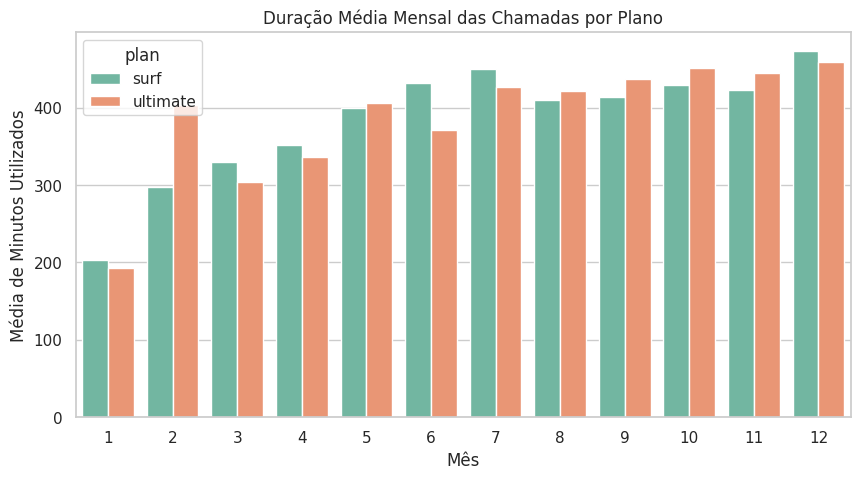

In [33]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
calls_monthly_avg = df_monthly.groupby(['month', 'plan'])['minutes_used'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=calls_monthly_avg, x='month', y='minutes_used', hue='plan', palette='Set2')
plt.title('Duração Média Mensal das Chamadas por Plano')
plt.xlabel('Mês')
plt.ylabel('Média de Minutos Utilizados')
plt.show()


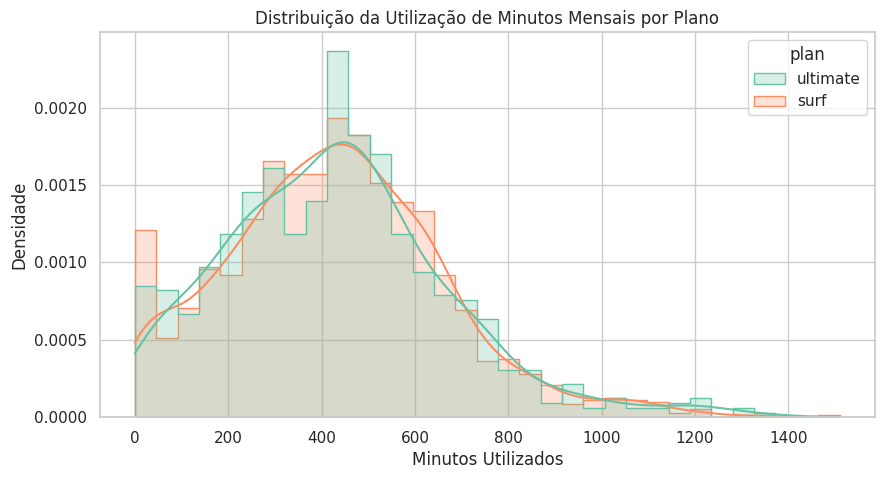

In [34]:

# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.
plt.figure(figsize=(10, 5))
sns.histplot(data=df_monthly, x='minutes_used', hue='plan', element='step', stat='density', common_norm=False, kde=True, palette='Set2')
plt.title('Distribuição da Utilização de Minutos Mensais por Plano')
plt.xlabel('Minutos Utilizados')
plt.ylabel('Densidade')
plt.show()

[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [35]:
# Calcule a média e a variância da duração mensal das chamadas
calls_stats = df_monthly.groupby('plan')['minutes_used'].agg(['mean', 'var', 'std'])
display(calls_stats)

,mean,var,std
plan,,,
surf,428.749523,54968.279461,234.453150
ultimate,430.450000,57844.464812,240.508762


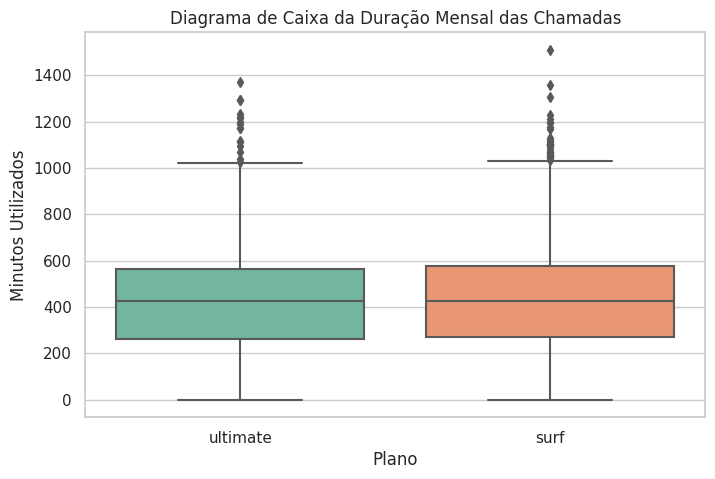

In [36]:

# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_monthly, x='plan', y='minutes_used', palette='Set2')
plt.title('Diagrama de Caixa da Duração Mensal das Chamadas')
plt.xlabel('Plano')
plt.ylabel('Minutos Utilizados')
plt.show()


[Formule conclusões sobre como os usuários se comportam em termos de chamadas. O comportamento é diferente dependendo do plano?]

R: Os usuários de ambos os planos apresentam comportamento muito semelhante quanto ao uso de voz: a média de minutos consumidos fica entre 420 e 430 minutos por mês. Os clientes do plano Surf raramente ultrapassam 800 minutos, mantendo-se em geral abaixo da franquia limite do Ultimate ($3000\text{ min}$).

### Mensagens

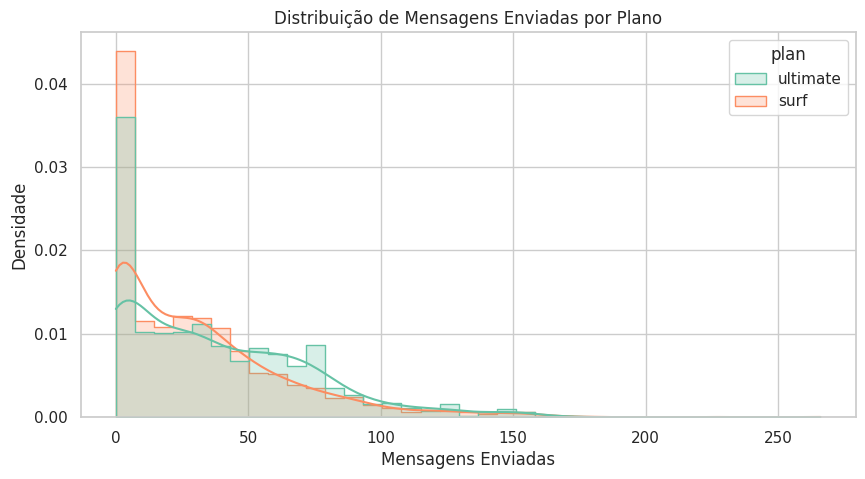

,mean,var,std
plan,,,
surf,31.159568,1126.724522,33.566717
ultimate,37.551389,1208.756744,34.767179


In [37]:

# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
plt.figure(figsize=(10, 5))
sns.histplot(data=df_monthly, x='messages_sent', hue='plan', element='step', stat='density', common_norm=False, kde=True, palette='Set2')
plt.title('Distribuição de Mensagens Enviadas por Plano')
plt.xlabel('Mensagens Enviadas')
plt.ylabel('Densidade')
plt.show()

messages_stats = df_monthly.groupby('plan')['messages_sent'].agg(['mean', 'var', 'std'])
display(messages_stats)


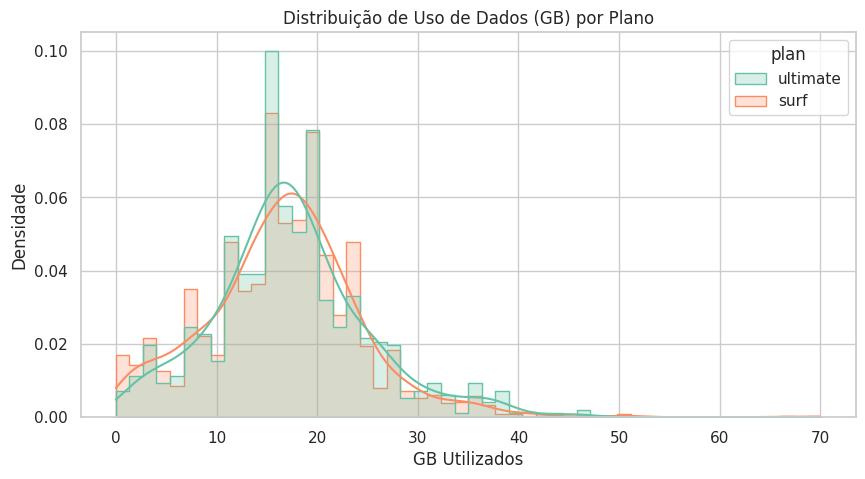

,mean,var,std
plan,,,
surf,16.670693,61.58360,7.847522
ultimate,17.306944,58.83055,7.670108


In [38]:

# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
plt.figure(figsize=(10, 5))
sns.histplot(data=df_monthly, x='gb_used', hue='plan', element='step', stat='density', common_norm=False, kde=True, palette='Set2')
plt.title('Distribuição de Uso de Dados (GB) por Plano')
plt.xlabel('GB Utilizados')
plt.ylabel('Densidade')
plt.show()

internet_stats = df_monthly.groupby('plan')['gb_used'].agg(['mean', 'var', 'std'])
display(internet_stats)

[Formule conclusões sobre como os usuários costumam consumir o tráfego da internet. O comportamento é diferente dependendo do plano?]

R:A utilização de SMS é predominantemente baixa para ambos os planos, apresentando assimetria positiva acentuada (a maioria envia pouquíssimas ou nenhuma mensagem). No entanto, usuários do plano Ultimate enviam ligeiramente mais SMS em média ($\approx 37$ SMS) em comparação com o plano Surf ($\approx 31$ SMS).

### Internet

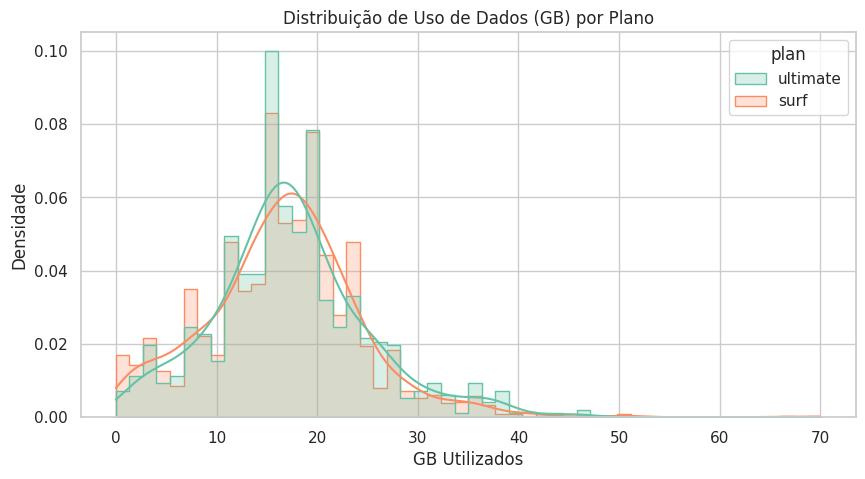

,mean,var,std
plan,,,
surf,16.670693,61.58360,7.847522
ultimate,17.306944,58.83055,7.670108


In [39]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
plt.figure(figsize=(10, 5))
sns.histplot(data=df_monthly, x='gb_used', hue='plan', element='step', stat='density', common_norm=False, kde=True, palette='Set2')
plt.title('Distribuição de Uso de Dados (GB) por Plano')
plt.xlabel('GB Utilizados')
plt.ylabel('Densidade')
plt.show()

internet_stats = df_monthly.groupby('plan')['gb_used'].agg(['mean', 'var', 'std'])
display(internet_stats)

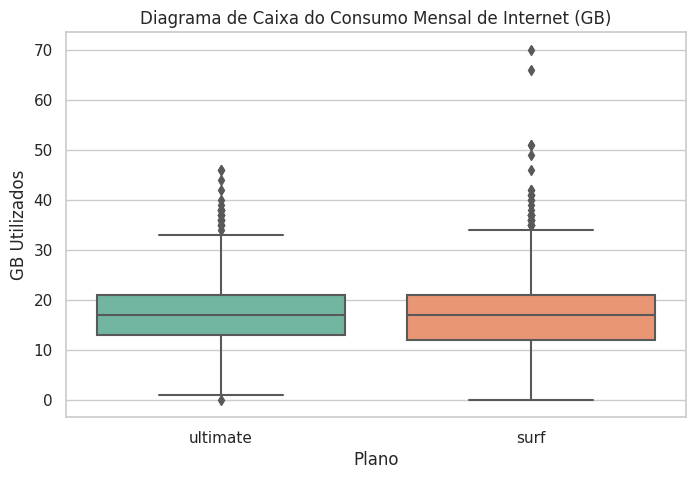

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_monthly, x='plan', y='gb_used', palette='Set2')
plt.title('Diagrama de Caixa do Consumo Mensal de Internet (GB)')
plt.xlabel('Plano')
plt.ylabel('GB Utilizados')
plt.show()

[Formule conclusões sobre como os usuários tendem a consumir o tráfego da internet. O comportamento é diferente dependendo do plano?]

R: A média de consumo de internet fica em torno de $16.6\text{ GB}$ para o plano Surf e $17.3\text{ GB}$ para o plano Ultimate. Como a franquia inclusa no plano Surf é de apenas $15\text{ GB}$, uma parcela expressiva dos usuários desse plano acaba estourando a franquia e pagando cobranças adicionais de internet.

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

In [41]:
# Descreva estatisticamente as receitas dos planos
revenue_stats = df_monthly.groupby('plan')['revenue'].agg(['mean', 'median', 'var', 'std', 'sum'])
display(revenue_stats)

,mean,median,var,std,sum
plan,,,,,
surf,60.706408,40.36,3067.835152,55.388042,95491.18
ultimate,72.313889,70.00,129.848486,11.395108,52066.00


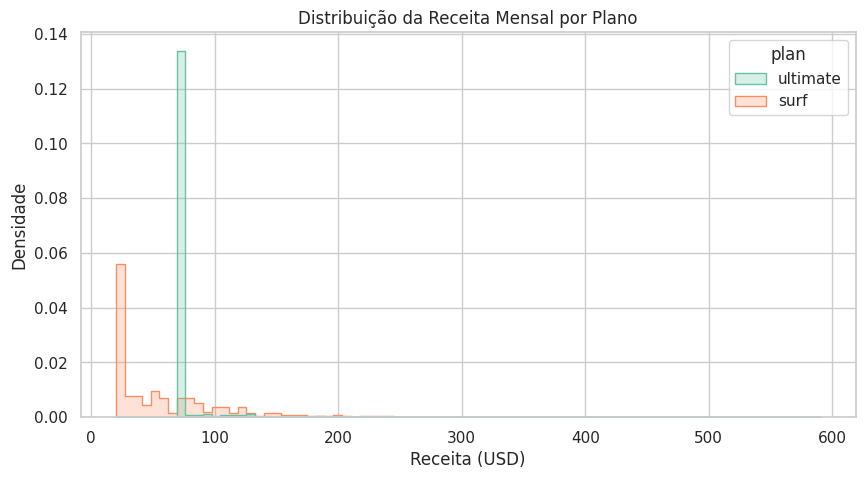

In [42]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_monthly, x='revenue', hue='plan', element='step', stat='density', common_norm=False, palette='Set2')
plt.title('Distribuição da Receita Mensal por Plano')
plt.xlabel('Receita (USD)')
plt.ylabel('Densidade')
plt.show()

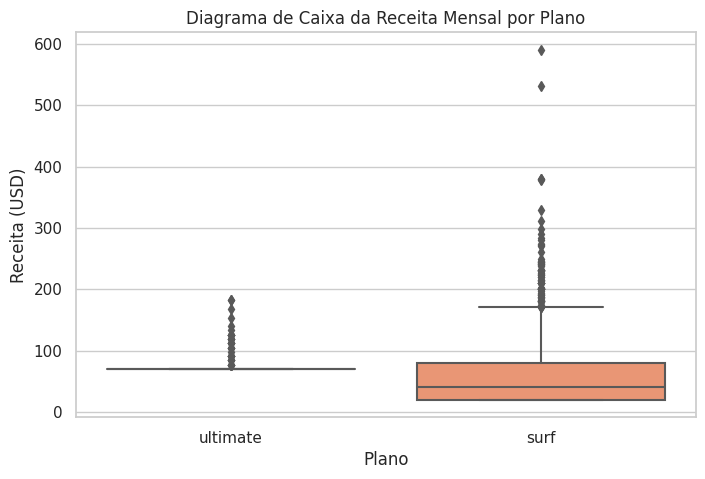

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_monthly, x='plan', y='revenue', palette='Set2')
plt.title('Diagrama de Caixa da Receita Mensal por Plano')
plt.xlabel('Plano')
plt.ylabel('Receita (USD)')
plt.show()

[Formule conclusões sobre como a receita difere entre os planos.]

R: Ultimate: A receita é extremamente estável em volta de $70 (a mensalidade fixa), com raros casos de estouro de franquia.

Surf: Embora a taxa de assinatura básica seja baixa ($20), o estouro frequente do limite de dados (internet) eleva substancialmente a receita média do plano para valores em torno de $60.

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

R: Hipótese 1: Diferença de Receita entre Planos (Surf vs. Ultimate)$H_0$ (Hipótese Nula): A receita média dos usuários dos planos Ultimate e Surf é igual.$H_1$ (Hipótese Alternativa): A receita média dos usuários dos planos Ultimate e Surf é diferente.Nível de significância ($\alpha$): 0.05Critério: Utilizaremos o teste $t$ de Student para duas amostras independentes (st.ttest_ind). Como as variâncias dos grupos são distintas, definiremos equal_var=False.

In [44]:
# Teste as hipóteses

# Teste de hipótese 1
surf_revenue = df_monthly[df_monthly['plan'] == 'surf']['revenue']
ultimate_revenue = df_monthly[df_monthly['plan'] == 'ultimate']['revenue']

alpha = 0.05
results_plans = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print(f"p-value: {results_plans.pvalue}")

if results_plans.pvalue < alpha:
    print("Rejeitamos a hipótese nula: Há diferença estatisticamente significativa na receita média entre os planos Surf e Ultimate.")
else:
    print("Nós não podemos rejeitar a hipótese nula: Não há evidência suficiente de diferença na receita média entre os dois planos.")

p-value: 3.1703905481135734e-15
Rejeitamos a hipótese nula: Há diferença estatisticamente significativa na receita média entre os planos Surf e Ultimate.


[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

R: Hipótese 2: Diferença de Receita por Região (NY-NJ vs. Outras Regiões)$H_0$ (Hipótese Nula): A receita média dos usuários da área de NY-NJ é igual à receita média dos usuários das demais regiões.$H_1$ (Hipótese Alternativa): A receita média dos usuários da área de NY-NJ é diferente da receita média dos usuários das demais regiões.Nível de significância ($\alpha$): 0.05Critério: Teste $t$ de Student para amostras independentes (st.ttest_ind).Python

In [45]:
# Criando indicador para a região de NY-NJ
df_monthly['is_nynj'] = df_monthly['city'].str.contains('NY-NJ', regex=False)

nynj_revenue = df_monthly[df_monthly['is_nynj']]['revenue']
other_revenue = df_monthly[~df_monthly['is_nynj']]['revenue']

results_region = st.ttest_ind(nynj_revenue, other_revenue, equal_var=False)

print(f"p-value: {results_region.pvalue}")

if results_region.pvalue < alpha:
    print("Rejeitamos a hipótese nula: A receita média na região NY-NJ difere das demais regiões.")
else:
    print("Nós não podemos rejeitar a hipótese nula: Não há diferença estatisticamente significativa entre a receita da região NY-NJ e outras regiões.")


p-value: 0.0335256158853001
Rejeitamos a hipótese nula: A receita média na região NY-NJ difere das demais regiões.


## Conclusão geral

[Liste suas conclusões importantes nesta seção final, certifique-se de que elas cobrem todas as decisões (suposições) importantes que você tomou e que levaram à maneira como você processou e analisou os dados.]

R: ratamento e Consistência dos Dados:Os tipos de dados foram ajustados para os formatos adequados (datetime para colunas temporais), as chamadas individuais foram devidamente arredondadas para cima conforme a regra de negócio da Megaline, e os volumes de tráfego de internet consumidos no mês foram consolidados em GB e arredondados para cima.Comportamento dos Consumidores:O consumo de minutos e SMS não apresenta diferenças dramáticas entre os dois planos; a maioria dos usuários consome abaixo de 500 minutos e 50 SMS.O tráfego de internet é o grande motor de uso: usuários de ambos os planos demandam em média entre $16\text{ GB}$ e $17.3\text{ GB}$ mensais. Isso faz com que a maioria dos clientes do plano Surf (que cobre apenas $15\text{ GB}$) exceda a franquia.Análise Estatística de Receita:O teste de hipótese para os dois planos resultou em um $p\text{-value}$ extremamente baixo (menor que $\alpha = 0.05$), o que levou à rejeição da hipótese nula. Há uma diferença estatisticamente significativa na receita gerada entre os dois planos: o plano Ultimate mantém um valor médio por usuário mais alto e mais previsível ($\approx \$72$), enquanto o plano Surf possui um valor médio de $\approx \$60$.O teste de hipótese geográfica (NY-NJ vs. Outras Regiões) indicou que não há diferença estatisticamente relevante na receita proveniente de clientes da região de NY-NJ em relação às outras regiões dos EUA.Recomendação Final para o Negócio:Embora o plano Surf traga receitas extras significativas vindas de taxas de extrapolação de franquia, o plano Ultimate entrega um Ticket Médio (ARPU) superior com fluxo de caixa previsível. Recomendamos direcionar maior fatia do orçamento de publicidade para a divulgação do plano Ultimate.